Projet Data Lucas Forey (sans pierre-yves): prédiction des heures à prix négatives sur le marché Day-ahead

Code de base pour préparer l'extract de données ENTSOE :

In [26]:
%matplotlib inline

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from entsoe import EntsoePandasClient

API_KEY = '1efc1e14-c733-4915-bd4f-cf2e11e6750f'  
client = EntsoePandasClient(api_key=API_KEY)
country_code = 'FR'

start = pd.Timestamp('2025-01-01', tz='Europe/Paris')
end = pd.Timestamp('2026-01-01', tz='Europe/Paris')

In [2]:
prices = client.query_day_ahead_prices(country_code, start=start, end=end)
load_forecast = client.query_load_forecast(country_code, start=start, end=end)
gen_forecast = client.query_wind_and_solar_forecast(country_code, start=start, end=end)

df = pd.DataFrame(prices)
df.columns = ['Price_EUR_MWh']

df_load = pd.DataFrame(load_forecast)
df_load.columns = ['Forecast_Load_MW']
df = df.join(df_load, how='outer')

if gen_forecast is not None and not gen_forecast.empty:
    df_gen = pd.DataFrame(gen_forecast)
    df['Forecast_Solar_MW'] = df_gen.get('Solar', 0)
    wind_cols = [c for c in df_gen.columns if 'Wind' in c]
    df['Forecast_Wind_MW'] = df_gen[wind_cols].sum(axis=1)


os.makedirs("Data/raw", exist_ok=True)
os.makedirs("Data/processed", exist_ok=True)

df.to_csv("Data/raw/entsoe_historique_brut.csv", index=True)

df = df.dropna()

df['Forecast_Residual_Load_MW'] = df['Forecast_Load_MW'] - df['Forecast_Solar_MW'] - df['Forecast_Wind_MW']
df['Is_Negative'] = df['Price_EUR_MWh'] < 0
df['Year'] = df.index.year
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month

df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df.to_csv("Data/processed/entsoe_features_clean.csv", index=True)

print(f"Le dataframe a {df.shape[0]} lignes et {df.shape[1]} colonnes")
print(f"On recense {df['Is_Negative'].sum()} heures négatives sur la période écoulée soit {df['Is_Negative'].sum()/(24*365.25)*100:.2f}% du temps")

Le dataframe a 8758 lignes et 16 colonnes
On recense 509 heures négatives sur la période écoulée soit 5.81% du temps


In [57]:
df_filtered = df[(df['Year'] >= 2020) & (df['Year'] <= 2025)]
summary_yearly = df_filtered.groupby('Year').agg(
    Heures_Negatives=('Is_Negative', 'sum'),
    Total_Heures=('Is_Negative', 'count')
)
summary_yearly['Pourcentage_Temps'] = (summary_yearly['Heures_Negatives'] / summary_yearly['Total_Heures']) * 100
summary_yearly = summary_yearly[['Heures_Negatives', 'Pourcentage_Temps']].round(2)

print("\nTableau récapitulatif (2020-2025) :")
print(summary_yearly)


Tableau récapitulatif (2020-2025) :
      Heures_Negatives  Pourcentage_Temps
Year                                     
2025               509               5.81


Evolution du pourcentage d'heures à prix day-ahead négatif en 2025

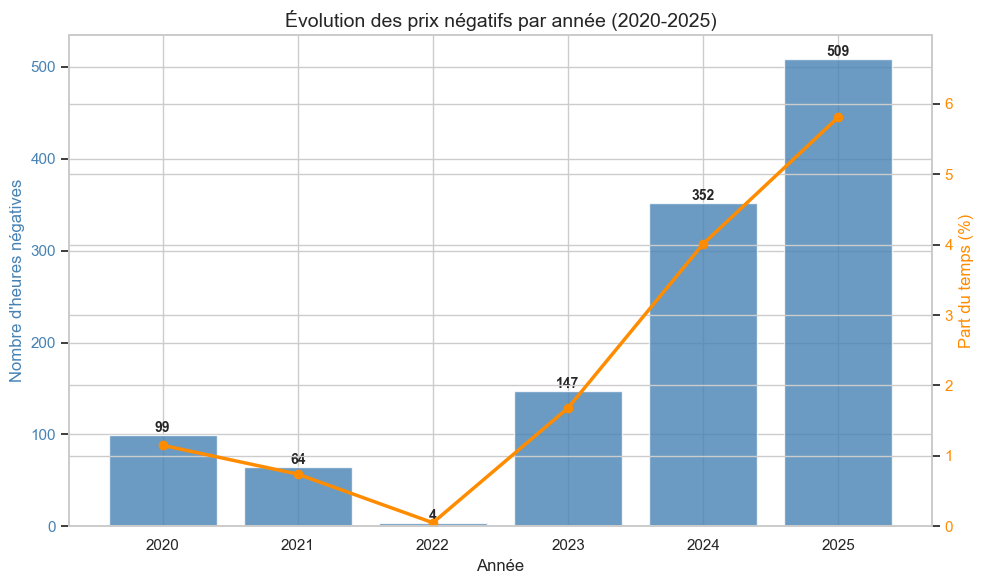

In [83]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

couleur_barres = 'steelblue'
ax1.set_xlabel('Année', fontsize=12)
ax1.set_ylabel('Nombre d\'heures négatives', color=couleur_barres, fontsize=12)
barres = ax1.bar(summary_yearly.index, summary_yearly['Heures_Negatives'], color=couleur_barres, alpha=0.8)
ax1.tick_params(axis='y', labelcolor=couleur_barres)
ax1.set_xticks(summary_yearly.index)

ax2 = ax1.twinx()
couleur_ligne = 'darkorange'
ax2.set_ylabel('Part du temps (%)', color=couleur_ligne, fontsize=12)
ax2.plot(summary_yearly.index, summary_yearly['Pourcentage_Temps'], color=couleur_ligne, marker='o', linewidth=2.5)
ax2.tick_params(axis='y', labelcolor=couleur_ligne)
ax2.set_ylim(0, summary_yearly['Pourcentage_Temps'].max() * 1.2) 

for barre in barres:
    hauteur = barre.get_height()
    ax1.text(barre.get_x() + barre.get_width()/2., hauteur,
             f'{int(hauteur)}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Évolution des prix négatifs par année (2020-2025)', fontsize=14)
fig.tight_layout()
plt.show()

Evolution des prix par mois en 2025 (détection visuelle de la saisonnalité prix négatifs)

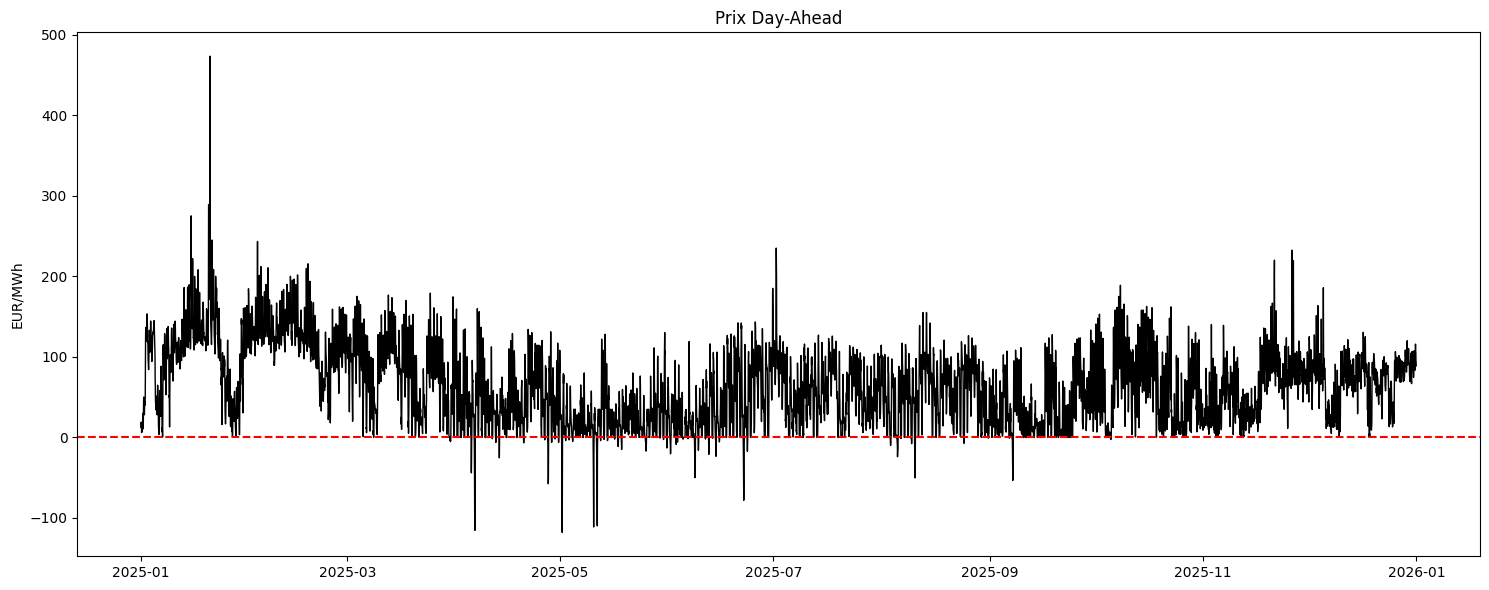

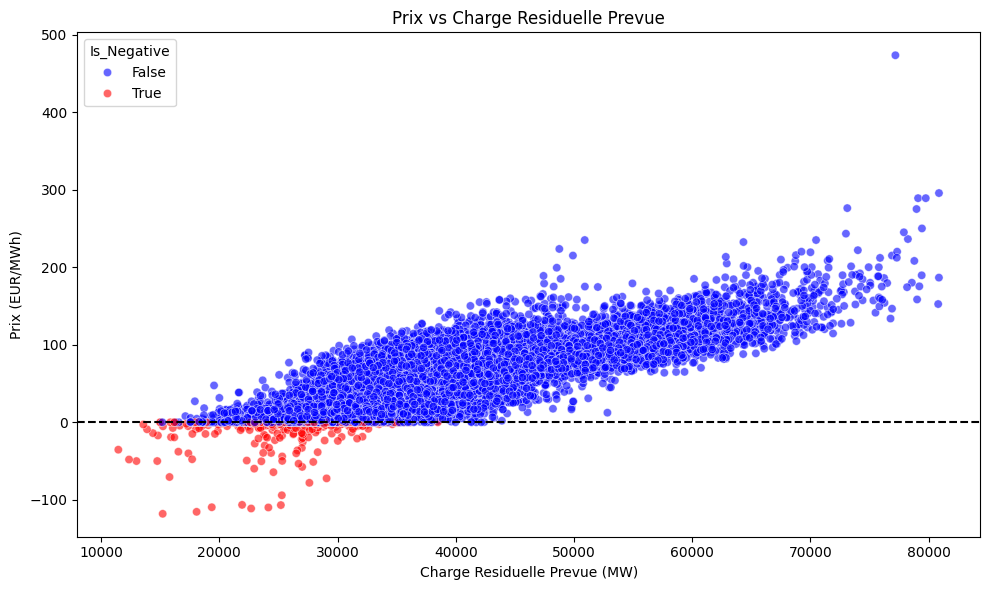

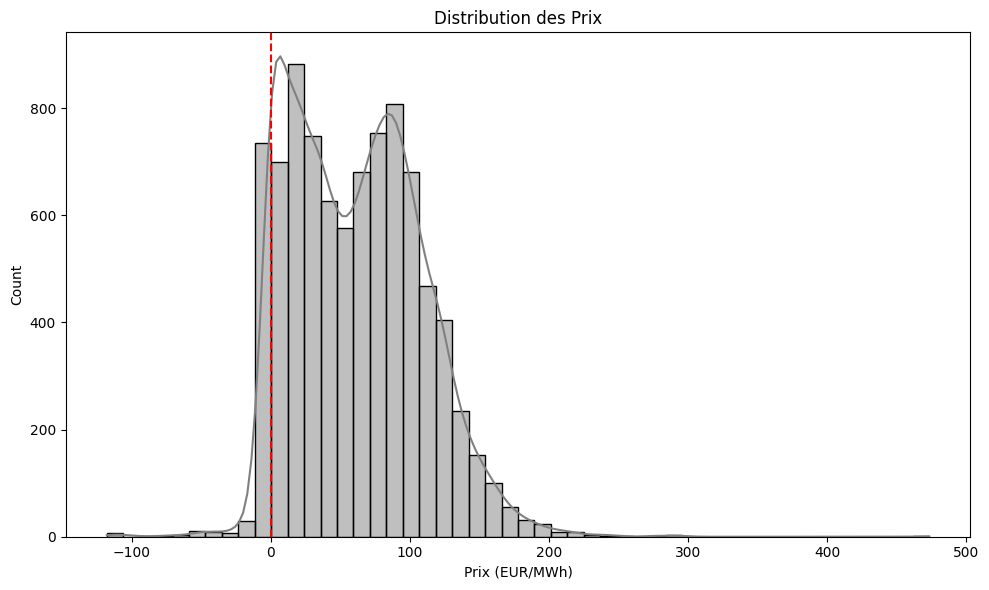

In [59]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Price_EUR_MWh'], color='black', linewidth=1)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Prix Day-Ahead')
plt.ylabel('EUR/MWh')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Forecast_Residual_Load_MW', y='Price_EUR_MWh', hue='Is_Negative', palette={False: 'blue', True: 'red'}, alpha=0.6)
plt.axhline(0, color='black', linestyle='--')
plt.title('Prix vs Charge Residuelle Prevue')
plt.xlabel('Charge Residuelle Prevue (MW)')
plt.ylabel('Prix (EUR/MWh)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Price_EUR_MWh'], bins=50, kde=True, color='gray')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution des Prix')
plt.xlabel('Prix (EUR/MWh)')
plt.tight_layout()
plt.show()

Visuellement, on observe sur l'année 2023 plusieurs situations où l'électricité a atteint un prix négatif. Ces situations semblent surtout intervenir en été.

Saisonnalité hebdomaraire/intra-journalière : 

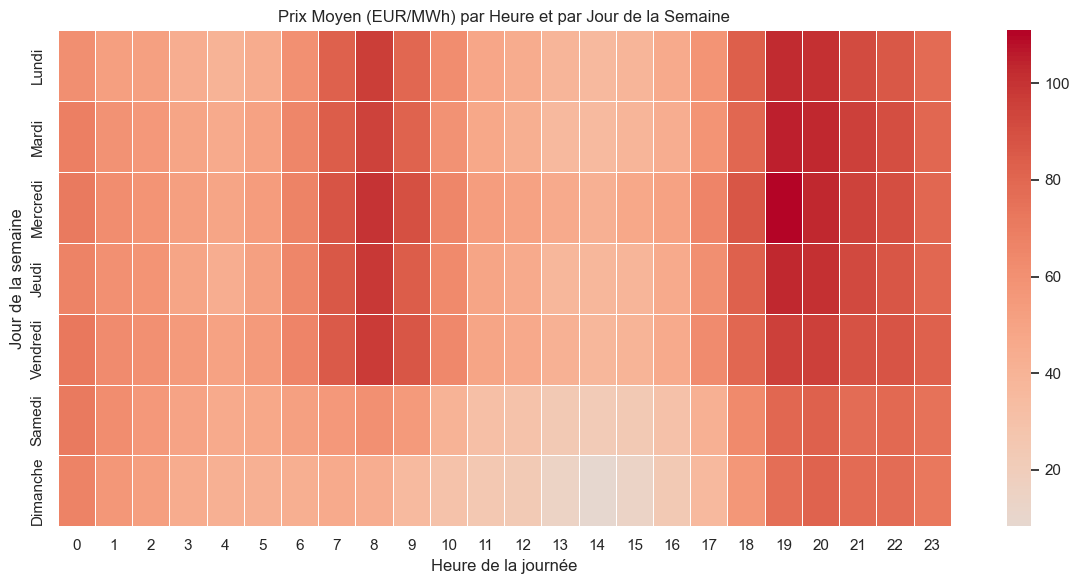

In [86]:
heatmap_data = df.groupby(['DayOfWeek', 'Hour'])['Price_EUR_MWh'].mean().unstack()
days = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
heatmap_data.index = days

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", center=0, annot=False, linewidths=.5)
plt.title('Prix Moyen (EUR/MWh) par Heure et par Jour de la Semaine')
plt.xlabel('Heure de la journée')
plt.ylabel('Jour de la semaine')
plt.tight_layout()
plt.show()

Cette heatmap permet de voir la corrélation entre prix faible et demande en électricité : les prix moyens les plus bas sont observés la nuit et en journée le week-end.

Nombre de prix négatifs par mois : 

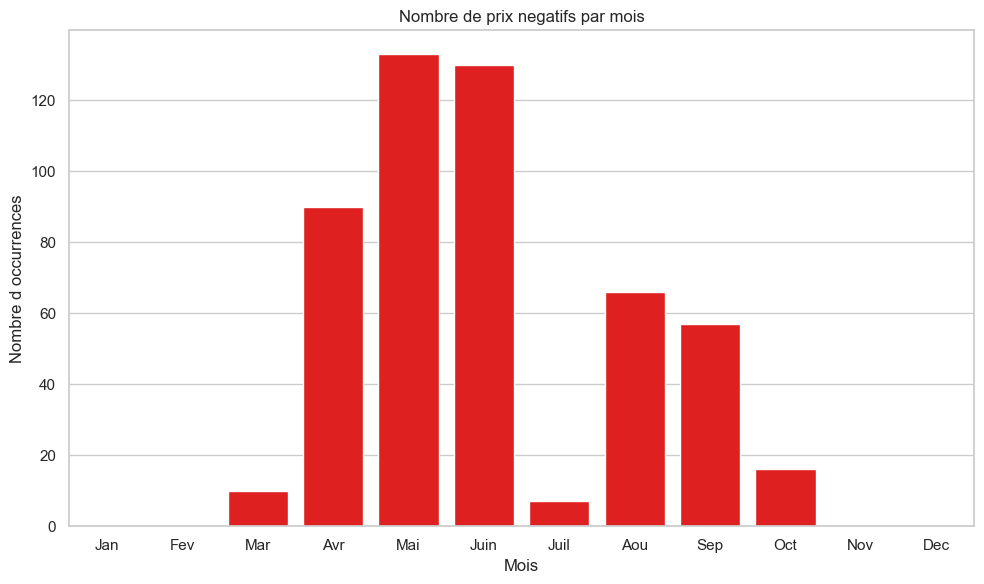

In [85]:
plt.figure(figsize=(10, 6))
negative_counts = df[df['Is_Negative']].groupby('Month').size()
all_months = pd.Series(0, index=range(1, 13))
negative_counts = negative_counts.add(all_months, fill_value=0)
month_names = ['Jan', 'Fev', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aou', 'Sep', 'Oct', 'Nov', 'Dec']
sns.barplot(x=month_names, y=negative_counts.values, color='red')
plt.title('Nombre de prix negatifs par mois')
plt.xlabel('Mois')
plt.ylabel('Nombre d occurrences')
plt.tight_layout()
plt.show()

La majorité des prix négatifs sont observés entre mai et septembre en 2023

Calcul de la corrélation :

In [30]:
correlation = df['Forecast_Residual_Load_MW'].corr(df['Price_EUR_MWh'])
print(f"Corrélation entre la charge résiduelle prévue et le prix : {correlation:.4f}")

Corrélation entre la charge résiduelle prévue et le prix : 0.7509


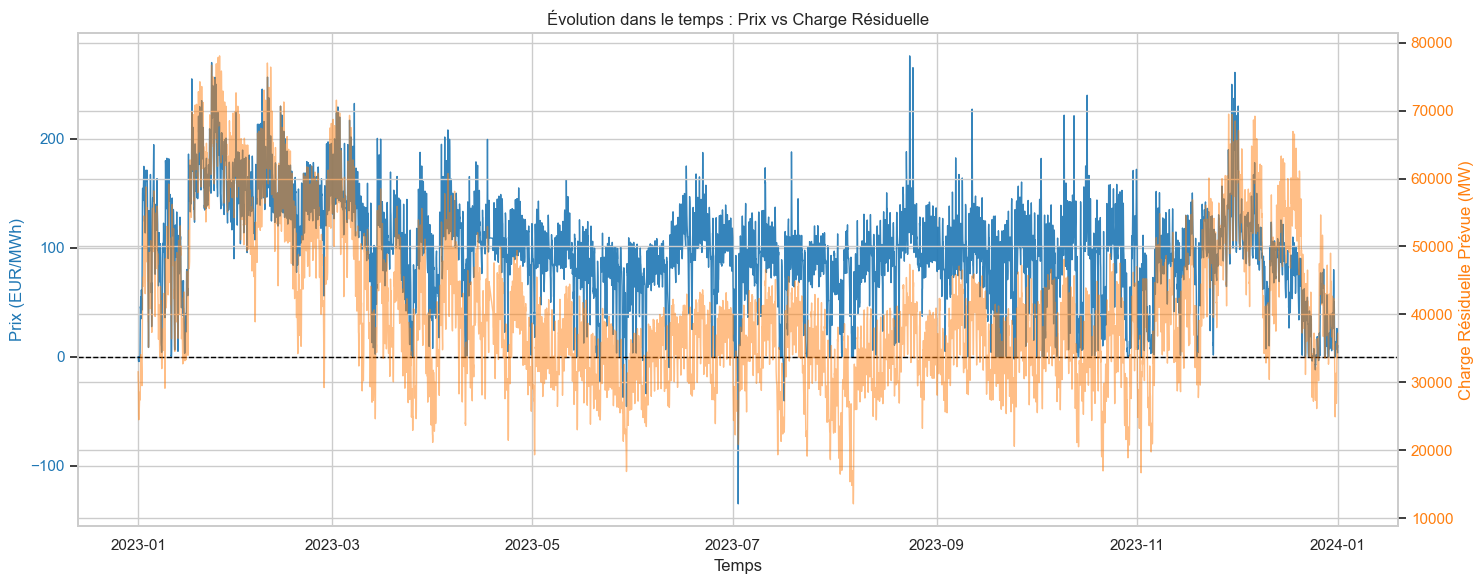

In [32]:
fig, ax1 = plt.subplots(figsize=(15, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Temps')
ax1.set_ylabel('Prix (EUR/MWh)', color=color1)
ax1.plot(df.index, df['Price_EUR_MWh'], color=color1, alpha=0.9, linewidth=1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Charge Résiduelle Prévue (MW)', color=color2)
ax2.plot(df.index, df['Forecast_Residual_Load_MW'], color=color2, alpha=0.5, linewidth=1)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Évolution dans le temps : Prix vs Charge Résiduelle')
fig.tight_layout()
plt.show()

Visualisation de la corrélation charge résiduelle/prix day-ahead

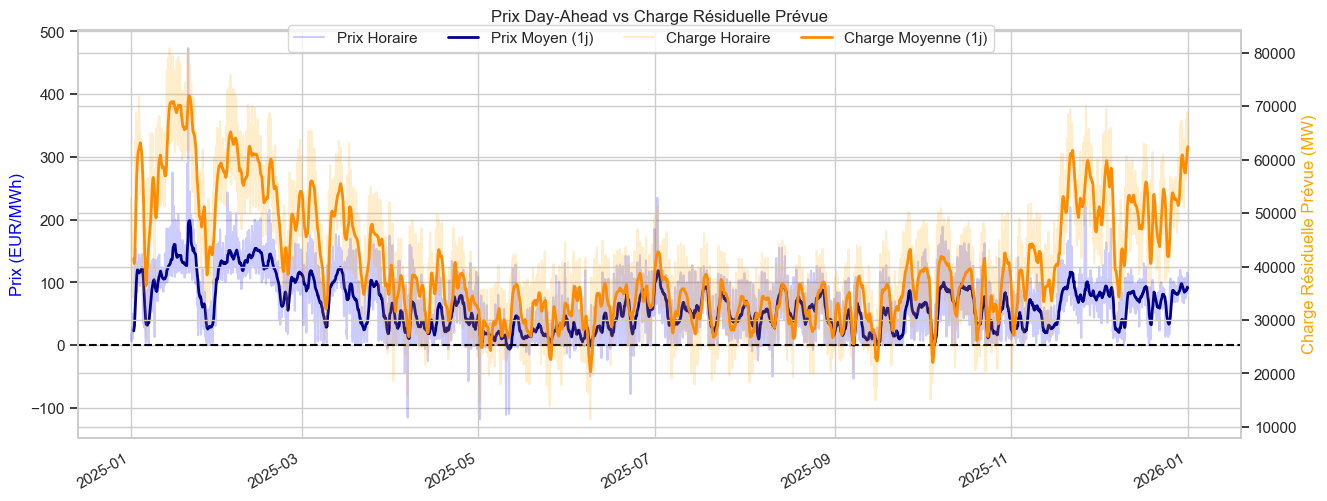

In [99]:
df['Price_Smooth'] = df['Price_EUR_MWh'].rolling(24).mean()
df['Load_Smooth'] = df['Forecast_Residual_Load_MW'].rolling(24).mean()

fig, ax1 = plt.subplots(figsize=(15, 6))
ax2 = ax1.twinx()

df['Price_EUR_MWh'].plot(ax=ax1, color='blue', alpha=0.2, label='Prix Horaire')
df['Price_Smooth'].plot(ax=ax1, color='darkblue', linewidth=2, label='Prix Moyen (1j)')

df['Forecast_Residual_Load_MW'].plot(ax=ax2, color='orange', alpha=0.2, label='Charge Horaire')
df['Load_Smooth'].plot(ax=ax2, color='darkorange', linewidth=2, label='Charge Moyenne (1j)')

ax1.set_ylabel('Prix (EUR/MWh)', color='blue')
ax2.set_ylabel('Charge Résiduelle Prévue (MW)', color='orange')
ax1.axhline(0, color='black', linestyle='--')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.9), ncol=4)
plt.title('Prix Day-Ahead vs Charge Résiduelle Prévue')
plt.show()

Premier algo : régression logistique

--- Baseline : Régression Logistique ---
              precision    recall  f1-score   support

           0       0.99      0.87      0.92      1604
           1       0.38      0.89      0.53       148

    accuracy                           0.87      1752
   macro avg       0.69      0.88      0.73      1752
weighted avg       0.94      0.87      0.89      1752

Prix moyen lors d'une fausse alerte : 22.37 EUR/MWh



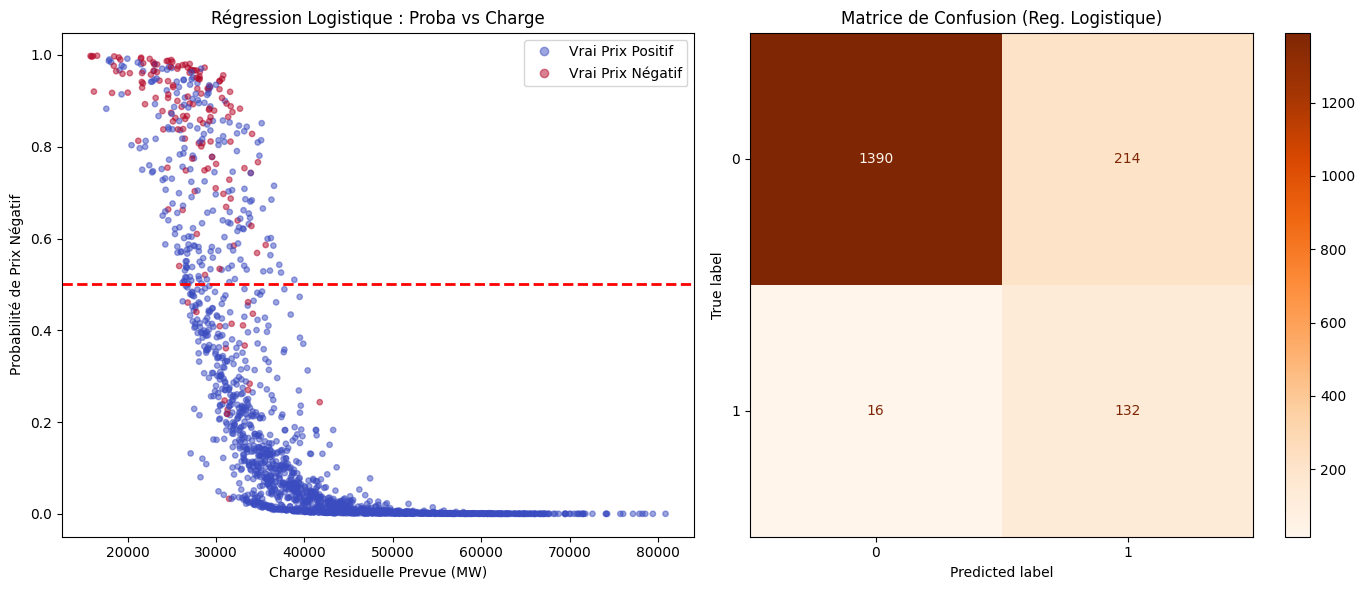

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

features = ['Forecast_Residual_Load_MW', 'Forecast_Solar_MW', 'Forecast_Wind_MW', 'Hour', 'DayOfWeek', 'Month']

X = df[features]
y_continuous = df['Price_EUR_MWh']
y_binary = (y_continuous <= 0).astype(int)

X_train, X_test, y_train_bin, y_test_bin, y_train_cont, y_test_cont = train_test_split(
    X, y_binary, y_continuous, test_size=0.2, random_state=42, stratify=y_binary
)

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(class_weight='balanced', random_state=42))
])

pipeline_lr.fit(X_train, y_train_bin)

y_pred_alerte = pipeline_lr.predict(X_test)
y_pred_proba = pipeline_lr.predict_proba(X_test)[:, 1]

fausses_alertes_mask = (y_pred_alerte == 1) & (y_test_bin == 0)
if fausses_alertes_mask.sum() > 0:
    prix_moyen_fp = y_test_cont[fausses_alertes_mask].mean()
else:
    prix_moyen_fp = 0

print("--- Baseline : Régression Logistique ---")
print(classification_report(y_test_bin, y_pred_alerte))
print(f"Prix moyen lors d'une fausse alerte : {prix_moyen_fp:.2f} EUR/MWh\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

scatter = ax1.scatter(X_test['Forecast_Residual_Load_MW'], y_pred_proba, c=y_test_bin, cmap='coolwarm', alpha=0.5, s=15)
ax1.axhline(0.5, color='red', linestyle='--', linewidth=2, label='Seuil (50%)')
ax1.set_xlabel('Charge Residuelle Prevue (MW)')
ax1.set_ylabel('Probabilité de Prix Négatif')
ax1.set_title('Régression Logistique : Proba vs Charge')
handles, _ = scatter.legend_elements()
ax1.legend(handles=handles, labels=['Vrai Prix Positif', 'Vrai Prix Négatif'], loc='upper right')

ConfusionMatrixDisplay.from_predictions(y_test_bin, y_pred_alerte, cmap='Oranges', ax=ax2)
ax2.set_title('Matrice de Confusion (Reg. Logistique)')

plt.tight_layout()
plt.show()

Poids des variables pour cette reg logistique :

--- Poids des variables (Régression Logistique) ---
Cible : 1 = Prix Négatif / 0 = Prix Positif

Forecast_Residual_Load_MW      : -2.9730
Forecast_Solar_MW              : +1.3824
Hour                           : -0.8949
Month                          : -0.2306
Forecast_Wind_MW               : +0.0573
DayOfWeek                      : +0.0451


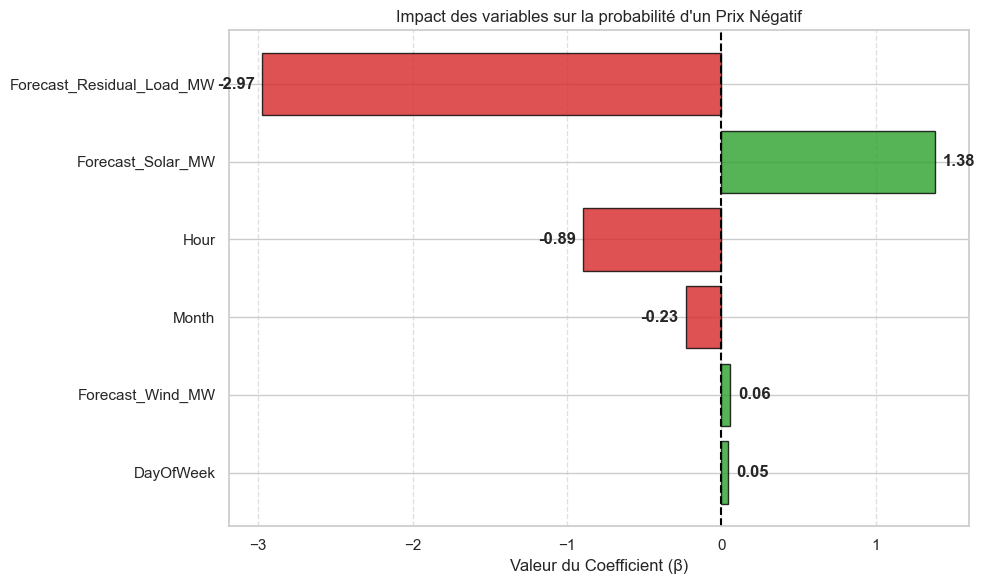

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Extraction du modèle et des coefficients depuis le pipeline
modele_logreg = pipeline_lr.named_steps['logreg']
coefficients = modele_logreg.coef_[0]

# 2. Création d'un DataFrame pour associer chaque variable à son poids
df_coefs = pd.DataFrame({
    'Variable': features,
    'Coefficient': coefficients
})

# 3. Tri par ordre d'importance (valeur absolue)
df_coefs['Importance_Absolue'] = df_coefs['Coefficient'].abs()
df_coefs = df_coefs.sort_values(by='Importance_Absolue', ascending=True)

# 4. Affichage texte
print("--- Poids des variables (Régression Logistique) ---")
print("Cible : 1 = Prix Négatif / 0 = Prix Positif\n")
for index, row in df_coefs.sort_values(by='Importance_Absolue', ascending=False).iterrows():
    signe = "+" if row['Coefficient'] > 0 else ""
    print(f"{row['Variable'].ljust(30)} : {signe}{row['Coefficient']:.4f}")

# 5. Visualisation graphique
plt.figure(figsize=(10, 6))

# Couleurs : Rouge si ça pousse vers un prix positif (coef < 0), Vert si ça pousse vers un prix négatif (coef > 0)
couleurs = ['tab:red' if c < 0 else 'tab:green' for c in df_coefs['Coefficient']]

plt.barh(df_coefs['Variable'], df_coefs['Coefficient'], color=couleurs, edgecolor='black', alpha=0.8)
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

plt.title('Impact des variables sur la probabilité d\'un Prix Négatif')
plt.xlabel('Valeur du Coefficient (\u03B2)')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Ajout des valeurs numériques sur les barres
for index, value in enumerate(df_coefs['Coefficient']):
    alignement = 'left' if value > 0 else 'right'
    decalage = 0.05 if value > 0 else -0.05
    plt.text(value + decalage, index, f"{value:.2f}", va='center', ha=alignement, fontweight='bold')

plt.tight_layout()
plt.show()

2e algo : K-nearest neighbors

--- Modèle KNN (k=5, seuil=0.4) ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1604
           1       0.73      0.71      0.72       148

    accuracy                           0.95      1752
   macro avg       0.85      0.84      0.85      1752
weighted avg       0.95      0.95      0.95      1752

Prix moyen lors d'une fausse alerte : 18.76 EUR/MWh



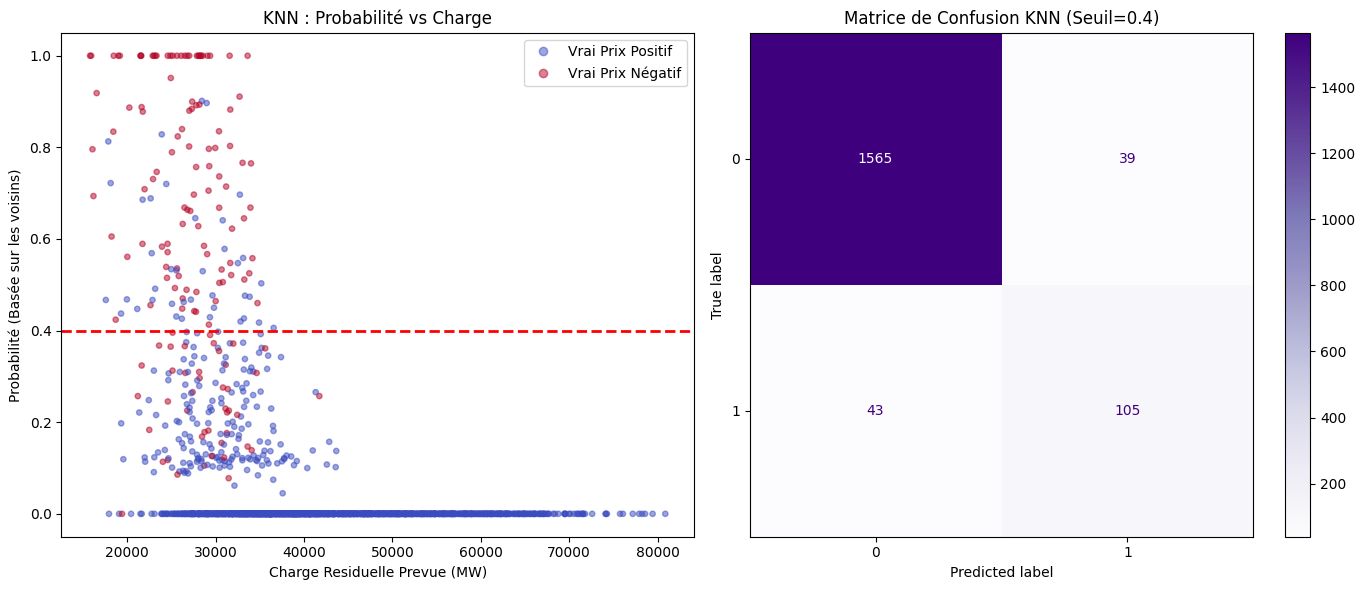

In [61]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

features = ['Forecast_Residual_Load_MW', 'Forecast_Solar_MW', 'Forecast_Wind_MW', 'Hour_sin','Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Month_sin', 'Month_cos']


X = df[features]
y_continuous = df['Price_EUR_MWh']
y_binary = (y_continuous <= 0).astype(int)

X_train, X_test, y_train_bin, y_test_bin, y_train_cont, y_test_cont = train_test_split(
    X, y_binary, y_continuous, test_size=0.2, random_state=42, stratify=y_binary
)

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=7, weights='distance'))
])

pipeline_knn.fit(X_train, y_train_bin)

y_pred_proba_knn = pipeline_knn.predict_proba(X_test)[:, 1]

seuil_knn = 0.4
y_pred_alerte_knn = (y_pred_proba_knn > seuil_knn).astype(int)

fausses_alertes_mask = (y_pred_alerte_knn == 1) & (y_test_bin == 0)
if fausses_alertes_mask.sum() > 0:
    prix_moyen_fp = y_test_cont[fausses_alertes_mask].mean()
else:
    prix_moyen_fp = 0

print(f"--- Modèle KNN (k=5, seuil={seuil_knn}) ---")
print(classification_report(y_test_bin, y_pred_alerte_knn))
print(f"Prix moyen lors d'une fausse alerte : {prix_moyen_fp:.2f} EUR/MWh\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


scatter = ax1.scatter(X_test['Forecast_Residual_Load_MW'], y_pred_proba_knn, c=y_test_bin, cmap='coolwarm', alpha=0.5, s=15)
ax1.axhline(seuil_knn, color='red', linestyle='--', linewidth=2, label=f'Seuil ({seuil_knn})')
ax1.set_xlabel('Charge Residuelle Prevue (MW)')
ax1.set_ylabel('Probabilité (Basée sur les voisins)')
ax1.set_title('KNN : Probabilité vs Charge')
handles, _ = scatter.legend_elements()
ax1.legend(handles=handles, labels=['Vrai Prix Positif', 'Vrai Prix Négatif'])

# Matrice de confusion
ConfusionMatrixDisplay.from_predictions(y_test_bin, y_pred_alerte_knn, cmap='Purples', ax=ax2)
ax2.set_title(f'Matrice de Confusion KNN (Seuil={seuil_knn})')

plt.tight_layout()
plt.show()

3e algo : XGBOOST

--- OPTIMISATION DU SEUIL ---
Meilleur seuil trouve : 0.68
F1-Score maximal atteint : 0.73

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1604
           1       0.68      0.80      0.73       148

    accuracy                           0.95      1752
   macro avg       0.83      0.88      0.85      1752
weighted avg       0.96      0.95      0.95      1752

Prix moyen lors d'une fausse alerte : 15.72 EUR/MWh



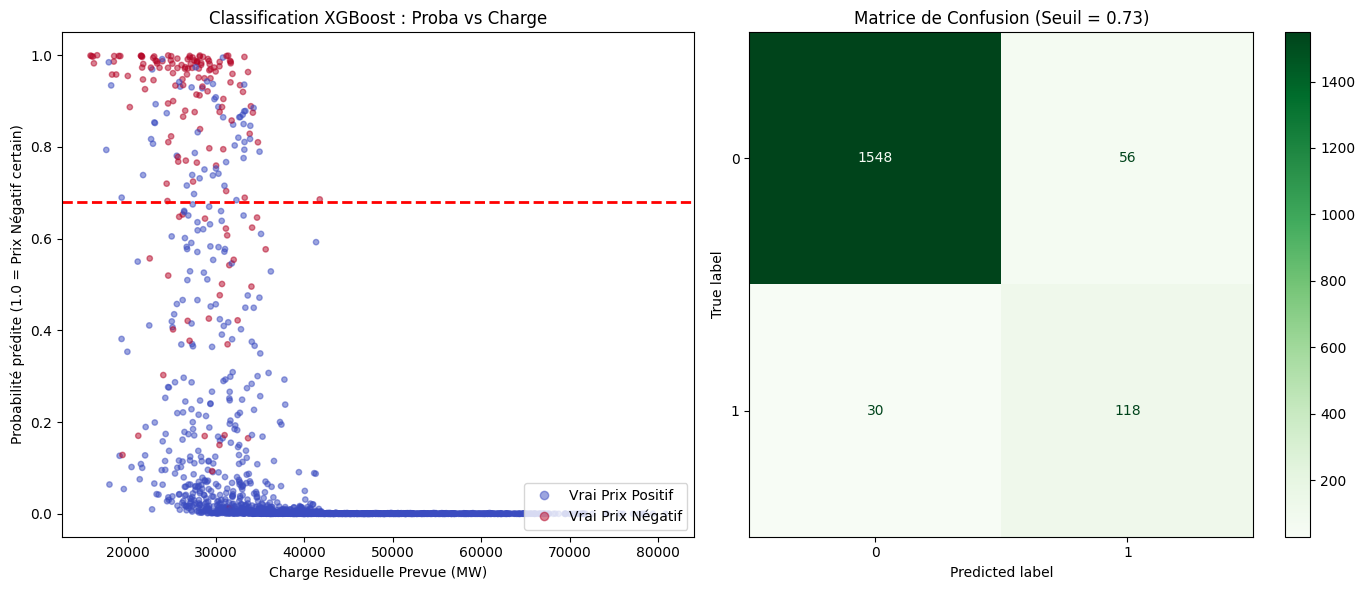

In [40]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

df_clean = df.dropna()
features = ['Forecast_Residual_Load_MW', 'Forecast_Solar_MW', 'Forecast_Wind_MW', 'Hour_sin','Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Month_sin', 'Month_cos']

X = df_clean[features]
# On conserve les prix continus pour calculer le coût des fausses alertes
y_continuous = df_clean['Price_EUR_MWh']
# On crée la cible binaire AVANT l'entraînement (1 = Prix négatif, 0 = Prix positif)
y_binary = (y_continuous <= 0).astype(int)

# On sépare les données en gardant les prix continus en parallèle (stratify est crucial ici)
X_train, X_test, y_train_bin, y_test_bin, y_train_cont, y_test_cont = train_test_split(
    X, y_binary, y_continuous, test_size=0.2, random_state=42, stratify=y_binary
)

# --- GESTION DU DÉSÉQUILIBRE DE CLASSES ---
# Formule standard XGBoost : ratio = nombre d'exemples négatifs (majoritaires) / positifs (minoritaires)
ratio_desequilibre = (len(y_train_bin) - y_train_bin.sum()) / y_train_bin.sum()

# Création du modèle de classification
model = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=5, 
    learning_rate=0.05, 
    random_state=42,
    scale_pos_weight=ratio_desequilibre # C'est ici que la magie opère pour les classes rares
)
model.fit(X_train, y_train_bin)

# On prédit la probabilité que le prix soit négatif (de 0 à 1)
y_pred_proba = model.predict_proba(X_test)[:, 1]

y_pred_proba = model.predict_proba(X_test)[:, 1]

# --- RECHERCHE AUTOMATIQUE DU MEILLEUR SEUIL ---
seuils_test = np.arange(0.01, 1.0, 0.01)
meilleur_seuil = 0.5
meilleur_f1 = 0.0

# On boucle sur tous les seuils possibles pour trouver le meilleur compromis
for seuil in seuils_test:
    y_pred_temp = (y_pred_proba >= seuil).astype(int)
    # On ignore les warnings si un seuil extrême met tout à 0
    f1_temp = f1_score(y_test_bin, y_pred_temp, zero_division=0) 
    
    if f1_temp > meilleur_f1:
        meilleur_f1 = f1_temp
        meilleur_seuil = seuil

print(f"--- OPTIMISATION DU SEUIL ---")
print(f"Meilleur seuil trouve : {meilleur_seuil:.2f}")
print(f"F1-Score maximal atteint : {meilleur_f1:.2f}\n")

# --- APPLICATION DU MEILLEUR SEUIL ---
seuil_proba = meilleur_seuil
y_pred_alerte = (y_pred_proba >= seuil_proba).astype(int)

# --- CALCUL DES FAUSSES ALERTES ---
fausses_alertes_mask = (y_pred_alerte == 1) & (y_test_bin == 0)
if fausses_alertes_mask.sum() > 0:
    prix_moyen_fp = y_test_cont[fausses_alertes_mask].mean()
else:
    prix_moyen_fp = 0

print(classification_report(y_test_bin, y_pred_alerte))
print(f"Prix moyen lors d'une fausse alerte : {prix_moyen_fp:.2f} EUR/MWh\n")

# --- VISUALISATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Graphique de gauche : Probabilité prédite vs Charge Résiduelle
scatter = ax1.scatter(X_test['Forecast_Residual_Load_MW'], y_pred_proba, c=y_test_bin, cmap='coolwarm', alpha=0.5, s=15)
ax1.axhline(seuil_proba, color='red', linestyle='--', linewidth=2, label=f'Seuil d\'Alerte ({seuil_proba*100}%)')
ax1.set_xlabel('Charge Residuelle Prevue (MW)')
ax1.set_ylabel('Probabilité prédite (1.0 = Prix Négatif certain)')
ax1.set_title('Classification XGBoost : Proba vs Charge')
# Création d'une légende propre
handles, _ = scatter.legend_elements()
ax1.legend(handles=handles, labels=['Vrai Prix Positif', 'Vrai Prix Négatif'], loc='lower right')

# Graphique de droite : Matrice de confusion
ConfusionMatrixDisplay.from_predictions(y_test_bin, y_pred_alerte, cmap='Greens', ax=ax2)
ax2.set_title('Matrice de Confusion (Seuil = 0.73)')

plt.tight_layout()
plt.show()
model.save_model("modele_xgboost.json")

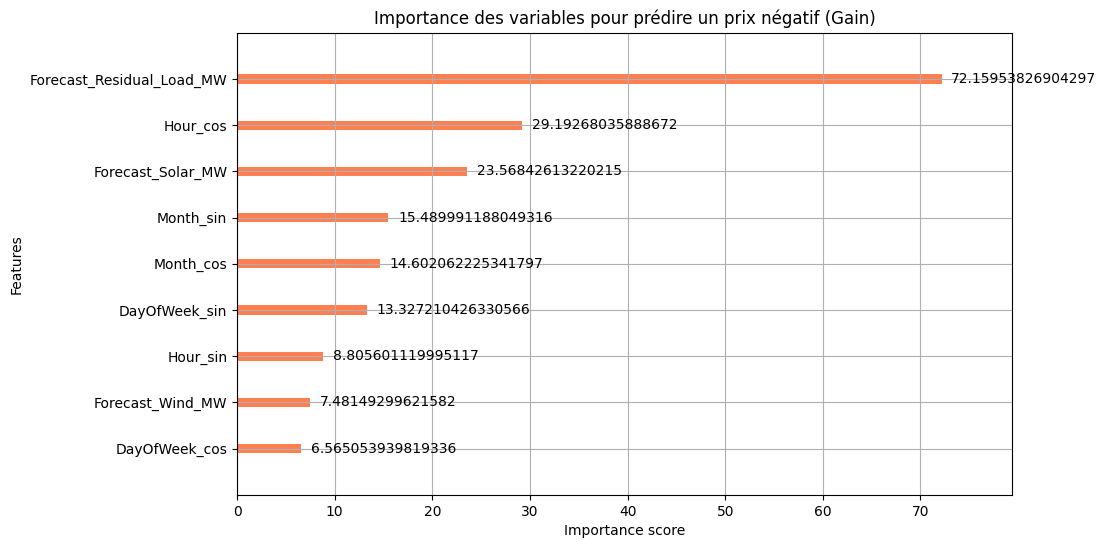

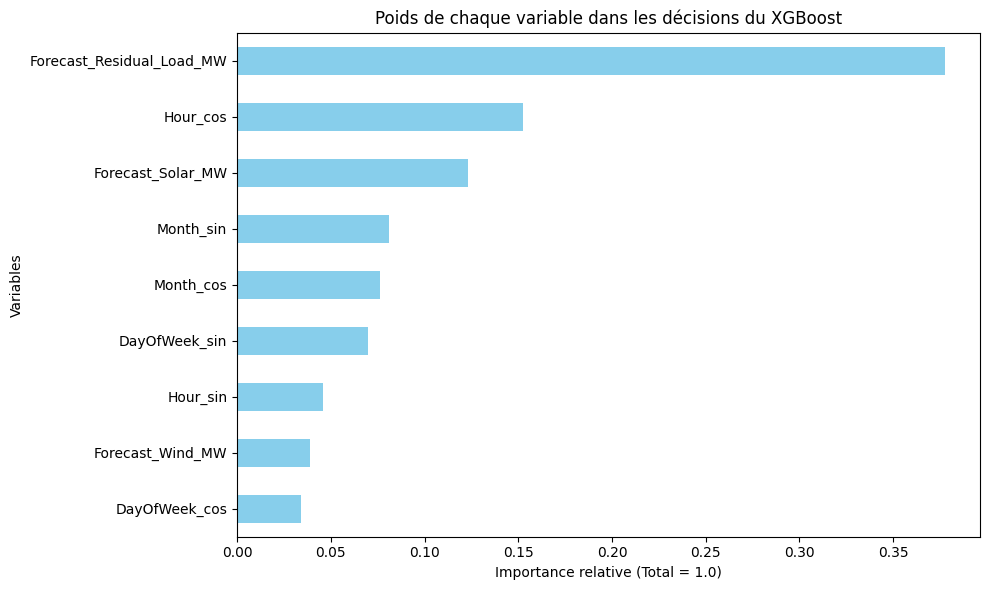

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb

# --- EXPLICABILITÉ GLOBALE : IMPORTANCE DES VARIABLES ---

# Méthode 1 : Utiliser la fonction native de XGBoost (très rapide)
# importance_type='gain' montre la valeur ajoutée réelle de la variable
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(model, importance_type='gain', ax=ax, 
                    title="Importance des variables pour prédire un prix négatif (Gain)",
                    color='coral')
plt.show()

# Méthode 2 : Créer un graphique personnalisé avec Pandas (plus joli)
# On récupère les scores d'importance calculés par le modèle
importances = pd.Series(model.feature_importances_, index=features)

# On trie et on affiche
plt.figure(figsize=(10, 6))
importances.sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title("Poids de chaque variable dans les décisions du XGBoost")
plt.xlabel("Importance relative (Total = 1.0)")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()